## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.


### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Topic 1 : Turbofan Engine Remaining Useful Life (RUL) Prediction

## Problem Statement

Aircraft engine failures are costly and unpredictable, and unplanned maintenance is far more expensive and risky than scheduled maintenance. Can we estimate how many operating cycles remain before failure using historical sensor telemetry, so that maintenance can be scheduled proactively?

## Goals
- Predict Remaining Useful Life (RUL) of a turbofan engine from sensor + operational setting data
- Minimize prediction error (RMSE) so maintenance teams can trust the estimate
- Identify which sensors are the strongest early indicators of degradation

## Approach
- Engineer the target column (RUL) from the raw cycle data
- Explore sensor trends over engine lifetime (degradation curves)
- Feature engineering: rolling means/slopes per sensor
- Modeling: start with Linear Regression / Random Forest baseline.


## Data Info
Data Source : NASA C-MAPSS Turbofan Engine Degradation Simulation, FD001 subset (Kaggle: `https://www.kaggle.com/datasets/behrad3d/nasa-cmaps/data`). 100 engines run to failure, 20,000+ rows total, 26 raw columns.

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| unit_number | int | Unique engine identifier |
| time_in_cycles | int | Operating cycle number for that engine |
| op_setting_1-3 | float | Operational settings (altitude, Mach number, throttle resolver angle) |
| sensor_1-21 | float | Sensor readings (temperatures, pressures, fan/core speeds, etc. — NASA does not name these individually) |
| RUL *(engineered)* | int | Target: cycles remaining until failure = max(time_in_cycles) - time_in_cycles, per engine |


In [5]:
# Load FD001 (space-separated, no header)
col_names = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

df1 = pd.read_csv('./data/train_FD001.txt', sep=r'\s+', header=None, names=col_names)
df1.tail()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [6]:
# Engineer the target column: Remaining Useful Life (RUL)
max_cycle = df1.groupby('unit_number')['time_in_cycles'].transform('max')
df1['RUL'] = max_cycle - df1['time_in_cycles']
df1[['unit_number', 'time_in_cycles', 'RUL']].head()


,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## EDA

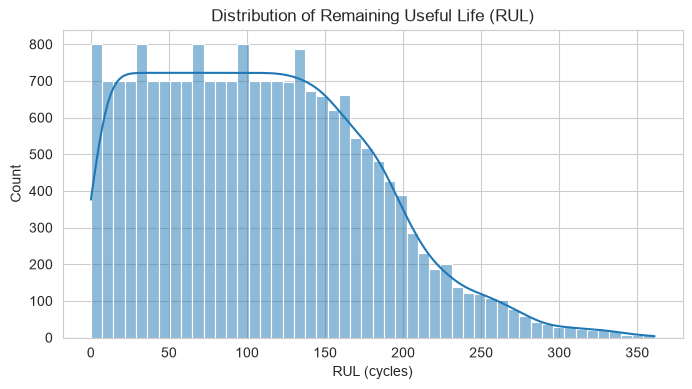

Numerical features: 27
Categorical features: 0
unit_number       0
time_in_cycles    0
op_setting_1      0
op_setting_2      0
op_setting_3      0
sensor_1          0
sensor_2          0
sensor_3          0
sensor_4          0
sensor_5          0
sensor_6          0
sensor_7          0
sensor_8          0
sensor_9          0
sensor_10         0
sensor_11         0
sensor_12         0
sensor_13         0
sensor_14         0
sensor_15         0
sensor_16         0
sensor_17         0
sensor_18         0
sensor_19         0
sensor_20         0
sensor_21         0
RUL               0
dtype: int64
RUL               1.000000
sensor_12         0.671983
sensor_7          0.657223
sensor_21         0.635662
sensor_20         0.629428
unit_number       0.078753
op_setting_2     -0.001948
op_setting_1     -0.003198
sensor_6         -0.128348
sensor_14        -0.306769
sensor_9         -0.390102
sensor_13        -0.562569
sensor_8         -0.563968
sensor_3         -0.584520
sensor_17        -0.60

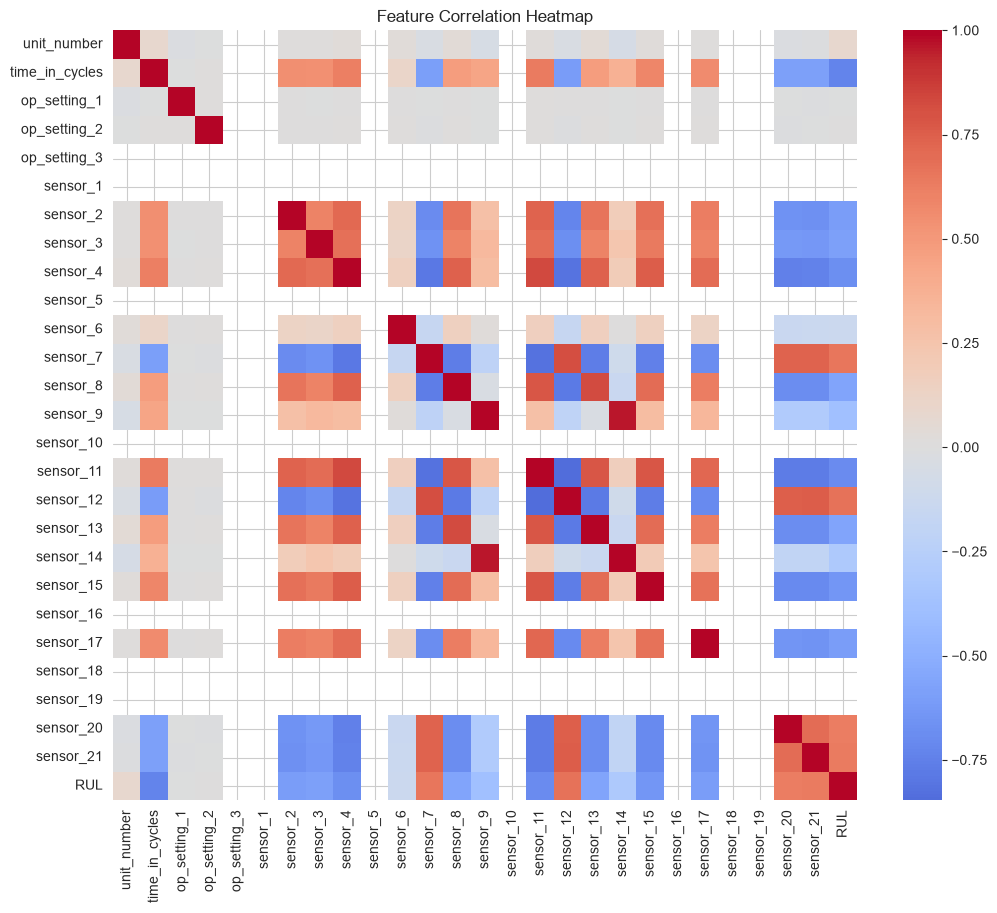

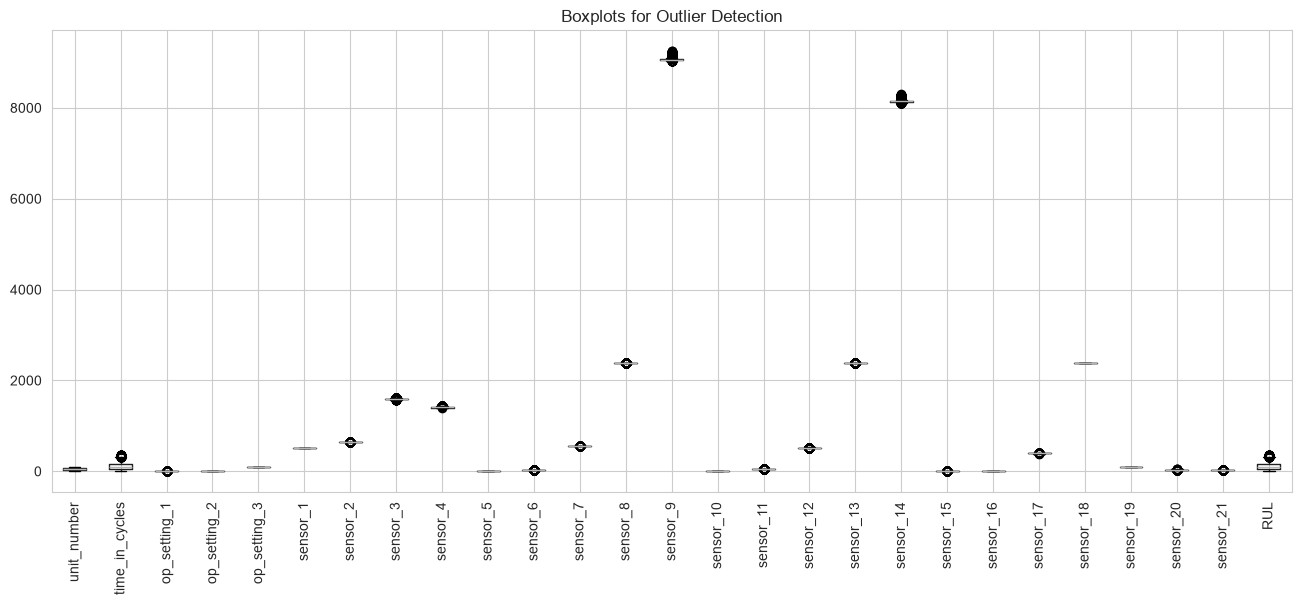

In [7]:
# Q1: Target column = RUL, represents cycles remaining before engine failure

# Q2: Is the target categorical or continuous? Plot distribution
# RUL is continuous (regression problem)
plt.figure(figsize=(8,4))
sns.histplot(df1['RUL'], bins=50, kde=True)
plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('RUL (cycles)')
plt.show()

# Q3: Feature types (categorical / numerical)
numerical_cols = df1.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df1.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

# Q4: Null values per feature
print(df1.isnull().sum())
# Plan: CMAPSS is simulated and typically has no missing values; if any appear, forward-fill
# per engine since these are sequential sensor readings.

# Q5: Correlation with target and with each other
corr_with_target = df1.corr(numeric_only=True)['RUL'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(12,10))
sns.heatmap(df1.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Q6: Outliers
plt.figure(figsize=(16,6))
df1[numerical_cols].boxplot(rot=90)
plt.title('Boxplots for Outlier Detection')
plt.show()
# Plan: sensors with constant/near-zero variance (a few sensors in CMAPSS never change) can be
# dropped; true outliers in physical sensor ranges are likely valid extreme wear readings, not
# data errors, so cap rather than remove them.


# Topic 2 : Steam Game Success/Rating Prediction

## Problem Statement

With 100k+ games competing for attention on Steam, what factors actually predict how well a game will be received by players?

## Goals
- Predict a game's positive review ratio from its structured metadata
- Identify which features (price, genre, platform support, release timing) most influence success

## Approach
- Engineer a target column from raw positive/negative review counts
- Use only structured columns (price, genres, platforms, release date) — avoid the free-text
  description field to keep this a non-NLP tabular problem
- Regression (Random Forest) with feature importance analysis


## Data Info
Data Source : Steam Games Dataset (Kaggle: `https://www.kaggle.com/datasets/fronkongames/steam-games-dataset`). 125,855 rows and 10 columns.

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| name | object | Game title |
| release_date | object | Release date |
| price | float | Price in USD |
| genres | object | Genre tags (comma-separated) |
| platforms | object | Supported platforms (Windows/Mac/Linux) |
| positive | int | Number of positive reviews |
| negative | int | Number of negative reviews |
| estimated_owners | object | Estimated owner range |
| positive_ratio *(engineered)* | float | Target: positive / (positive + negative) |


In [11]:
df2 = pd.read_csv('./data/steam_games.csv')
print(df2.shape)
df2.tail()

(125855, 39)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
3249570,Sotsugyo Omedeto,"Mar 1, 2026",0 - 0,0,0,8.09,0,0,A survival trial game set in an all-girls scho...,"['English', 'Japanese', 'Korean', 'Simplified ...",...,0,0,0,SuperLoki,SuperLoki,"Single-player,Steam Achievements,Camera Comfor...","Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2218150,Island on cloud,"Feb 24, 2026",0 - 0,0,0,0.59,0,0,"A game with a quirky art style, resembling ani...","['English', 'Simplified Chinese']",...,0,0,0,7th Ghost,7th Ghost,"Single-player,Family Sharing","Adventure,RPG",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3788650,Rosie Planet,"Mar 1, 2026",0 - 0,0,0,12.99,0,0,Jam Packed full with Videogame Rosie Planet is...,['English'],...,0,0,0,Connor Leary,Connor Leary,"Single-player,Full controller support,Playable...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3509140,Fear Effect 2: Retro Helix,"Feb 27, 2026",0 - 0,0,0,9.99,0,0,Return to 2048 Hong Kong in the groundbreaking...,['English'],...,0,0,0,Implicit Conversions,Limited Run Games,"Single-player,Steam Achievements,Full controll...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4247310,Project Liminal 2,"Mar 2, 2026",0 - 0,0,0,2.51,0,0,All events and characters are fictional. Any r...,"['English', 'Russian', 'Japanese']",...,0,0,0,AquaHeaven Studios,TXC,"Single-player,Steam Achievements,Full controll...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [12]:
# Engineer the target column
df2 = df2[(df2['positive'] + df2['negative']) > 0]  # drop games with zero reviews
df2['positive_ratio'] = df2['positive'] / (df2['positive'] + df2['negative'])
df2[['name', 'positive', 'negative', 'positive_ratio']].head()


KeyError: 'positive'

In [ ]:
# --- EDA ---

# Q1: Target column = positive_ratio, represents the share of reviews that are positive

# Q2: Continuous target -> regression problem. Distribution:
plt.figure(figsize=(8,4))
sns.histplot(df2['positive_ratio'], bins=50, kde=True)
plt.title('Distribution of Positive Review Ratio')
plt.show()

# Q3: Feature types
numerical_cols = df2.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df2.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

# Q4: Null values
print(df2.isnull().sum())
# Plan: drop rows missing price/genre (small fraction expected); impute missing platform
# flags as False rather than dropping.

# Q5: Correlation with target
print(df2.corr(numeric_only=True)['positive_ratio'].sort_values(ascending=False))

plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Q6: Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df2['price'])
plt.title('Price Outliers')
plt.show()
# Plan: cap extreme prices (e.g., collector's editions/bundles) at a reasonable percentile
# rather than dropping, since they are legitimate data points.


# Topic 3 : Aviation Accident Severity Prediction

## Problem Statement

Given the circumstances of a flight (aircraft type, engine type, weather, phase of flight), can we predict accident severity to help identify higher-risk conditions?

## Goals
- Classify accident injury severity from structured incident data
- Surface which operational/mechanical factors (engine type, aircraft category, weather) most
  strongly predict severe outcomes

## Approach
- Use only structured fields (exclude any free-text narrative/remarks column)
- Classification (Random Forest) with class-imbalance handling (class weights or SMOTE),
  since fatal accidents are the minority class
- Tie mechanical/engine-type findings back to an engineering perspective


## Data Info
Data Source : NTSB Aviation Accident Database, 1962-2023 (Kaggle: `https://www.kaggle.com/datasets/yassereleraky/aviation-accident-ntsb?select=AviationData.csv`). ~85,000-90,000 rows, ~30 structured columns (confirm exact count once loaded).

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| Event.Date | object | Date of the accident |
| Location | object | Accident location |
| Injury.Severity | object | Target: Fatal / Serious / Minor / None |
| Aircraft.Category | object | Type of aircraft (airplane, helicopter, etc.) |
| Make / Model | object | Aircraft manufacturer and model |
| Engine.Type | object | Engine type (reciprocating, turbofan, turboprop, etc.) |
| Number.of.Engines | float | Number of engines on the aircraft |
| Weather.Condition | object | VMC (visual) or IMC (instrument) conditions |
| Broad.Phase.of.Flight | object | Flight phase at time of accident (takeoff, cruise, landing, etc.) |


In [ ]:
# NOTE: NTSB's own source data is pipe-delimited text even though it's often labeled 'CSV'.
# Peek at the raw file first to confirm the delimiter before loading:
with open('./data/AviationData.txt', encoding='latin1') as f:
    print(f.readline())


In [ ]:
# Adjust sep to match what you saw above: '|' is most common for NTSB exports,
# '\t' if it looks tab-separated, or ',' if it's genuinely comma-separated.
df3 = pd.read_csv('AviationData.txt', sep='|', encoding='latin1', low_memory=False)
df3.columns = df3.columns.str.strip()  # NTSB exports often have padded column names
df3.head()


In [ ]:
# --- EDA ---

# Q1: Target column = Injury.Severity, represents accident outcome severity

# Q2: Categorical target -> classification problem. Class balance:
plt.figure(figsize=(8,4))
df3['Injury.Severity'].value_counts().plot(kind='bar')
plt.title('Injury Severity Class Distribution')
plt.show()
# Expect strong imbalance: 'Fatal' is typically a small minority relative to non-fatal outcomes

# Q3: Feature types
numerical_cols = df3.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df3.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

# Q4: Null values
print(df3.isnull().sum().sort_values(ascending=False).head(15))
# Plan: drop columns with very high missingness (e.g., far-back historical records with
# sparse fields); impute Weather.Condition/Engine.Type with 'Unknown' category rather than
# dropping rows, since severity may still be inferable from other fields.

# Q5: Correlation / association with target
# Injury.Severity is categorical, so use crosstabs instead of Pearson correlation
print(pd.crosstab(df3['Weather.Condition'], df3['Injury.Severity'], normalize='index'))

# Q6: Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df3['Number.of.Engines'])
plt.title('Number of Engines Outliers')
plt.show()
# Plan: values like 0 or unusually high engine counts likely reflect data-entry errors and
# should be reviewed/corrected rather than blindly dropped.


# Topic 4 : Weather Temperature Prediction

## Problem Statement

Weather conditions affect everything from outdoor mechanical equipment performance to flight safety. Can we predict temperature (or precipitation type) from other atmospheric measurements?

## Goals
- Predict apparent temperature from humidity, wind, pressure, and visibility
- Quantify which atmospheric variables most strongly drive temperature outcomes

## Approach
- Clean known data issues (drop constant 'Loud Cover' column, remove duplicate rows)
- Regression: Linear Regression baseline, then Random Forest
- Optional stretch: compare against Topic 3's Weather.Condition field for a cross-dataset
  discussion of weather's role in aviation risk


## Data Info
Data Source : Weather in Szeged, Hungary 2006-2016 (Kaggle: `https://www.kaggle.com/datasets/budincsevity/szeged-weather?select=weatherHistory.csv`). 96.5k rows, 12 columns.

## Data Dictionary
| Column | Type | Description |
| --- | --- | --- |
| Formatted Date | object | Timestamp of the hourly observation |
| Summary | object | Short weather summary category |
| Precip Type | object | rain / snow / null |
| Temperature (C) | float | Target: air temperature in Celsius |
| Apparent Temperature (C) | float | 'Feels like' temperature |
| Humidity | float | Relative humidity (0-1) |
| Wind Speed (km/h) | float | Wind speed |
| Wind Bearing (degrees) | int | Wind direction |
| Visibility (km) | float | Visibility distance |
| Pressure (millibars) | float | Atmospheric pressure |


In [ ]:
df4 = pd.read_csv('./data/weatherHistory.csv')
df4.head()


In [ ]:
# Known data-quality fixes from prior EDA on this dataset
if 'Loud Cover' in df4.columns:
    df4 = df4.drop(columns=['Loud Cover'])  # constant column, all zeros
df4 = df4.drop_duplicates()
df4.shape


In [ ]:
# --- EDA ---

# Q1: Target column = Temperature (C), represents measured air temperature

# Q2: Continuous target -> regression problem. Distribution:
plt.figure(figsize=(8,4))
sns.histplot(df4['Temperature (C)'], bins=50, kde=True)
plt.title('Distribution of Temperature (C)')
plt.show()

# Q3: Feature types
numerical_cols = df4.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df4.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

# Q4: Null values
print(df4.isnull().sum())
# Plan: 'Precip Type' has a small number of nulls; forward-fill since precip type tends to
# persist across consecutive hourly readings.

# Q5: Correlation with target
corr_with_target = df4.corr(numeric_only=True)['Temperature (C)'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10,8))
sns.heatmap(df4.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Q6: Outliers
plt.figure(figsize=(14,6))
df4[numerical_cols].boxplot(rot=90)
plt.title('Boxplots for Outlier Detection')
plt.show()
# Plan: Humidity/Pressure values of 0 are known sensor errors in this dataset and should be
# treated as missing rather than true zeros; Wind Speed values above ~60 km/h are rare but
# plausible extreme weather events, so cap rather than drop.
